# AI-ML Assignment – 8
## Topic: Handwritten Digit Recognition using Artificial Neural Networks (ANN)

**Author:** Arsh  
**Date:** July 30, 2026  

---

### Objective
Develop an Artificial Neural Network (ANN) using TensorFlow/Keras to classify handwritten digits (0–9) from the MNIST dataset in CSV format. The assignment involves data understanding, data preprocessing, network construction, training, performance evaluation, and drawing key machine learning conclusions.

# Task 1: Data Understanding (2 Marks)

In this section, we will:
1. Load the MNIST training and test datasets using Pandas.
2. Display the first five records.
3. Identify the input features and target variable.
4. Display the dataset dimensions and summary information.
5. Display one sample handwritten digit using Matplotlib.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# 1. Load the dataset using Pandas
print("Loading datasets...")
train_df = pd.read_csv('data/mnist_train.csv')
test_df = pd.read_csv('data/mnist_test.csv')

# Concatenate to form the complete dataset for exploration and split
df = pd.concat([train_df, test_df], ignore_index=True)
print(f"Loaded {len(train_df)} training records and {len(test_df)} test records.")
print(f"Combined dataset contains {len(df)} total records.")

# 2. Display the first five records
df.head()

Loading datasets...
Loaded 60000 training records and 10000 test records.
Combined dataset contains 70000 total records.


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,1x11,1x12,1x13,1x14,1x15,1x16,1x17,1x18,1x19,1x20,1x21,1x22,1x23,1x24,1x25,1x26,1x27,1x28,2x1,2x2,2x3,2x4,2x5,2x6,2x7,2x8,2x9,2x10,2x11,...,27x17,27x18,27x19,27x20,27x21,27x22,27x23,27x24,27x25,27x26,27x27,27x28,28x1,28x2,28x3,28x4,28x5,28x6,28x7,28x8,28x9,28x10,28x11,28x12,28x13,28x14,28x15,28x16,28x17,28x18,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,147,252,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Identification of Features and Target Variable:
- **Input Features ($X$):** The 784 pixel intensity columns named `1x1` to `28x28` representing the flattened $28 \times 28$ grayscale images. Each pixel value ranges from 0 (black/background) to 255 (white/foreground).
- **Target Variable ($y$):** The `label` column containing the actual digit (integer 0–9) that the image represents.

In [2]:
# 4. Display dataset dimensions and summary info
print("=== Dataset Dimensions ===")
print(f"Shape of combined dataset: {df.shape}")
print(f"Shape of train dataset: {train_df.shape}")
print(f"Shape of test dataset: {test_df.shape}\n")

print("=== Dataset Summary Information ===")
df.info(max_cols=10)  # Limiting column print to avoid flooding

=== Dataset Dimensions ===
Shape of combined dataset: (70000, 785)
Shape of train dataset: (60000, 785)
Shape of test dataset: (10000, 785)

=== Dataset Summary Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 419.2 MB


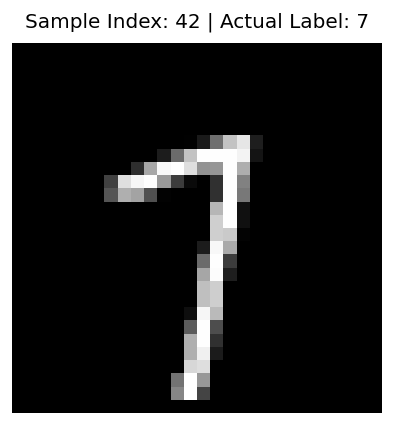

In [3]:
# 5. Display one sample handwritten digit using Matplotlib
sample_index = 42  # You can change this to view different samples
sample_row = df.iloc[sample_index]
sample_label = sample_row['label']
sample_pixels = sample_row.drop('label').values.astype('float32')

# Reshape to 28x28 pixels for display
sample_image = sample_pixels.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap='gray')
plt.title(f"Sample Index: {sample_index} | Actual Label: {sample_label}", fontsize=12, pad=10)
plt.axis('off')
plt.show()

# Task 2: Data Preprocessing (2 Marks)

In this section, we will:
1. Check for missing values in the dataset.
2. Separate input features and the target variable.
3. Normalize pixel values to the range 0–1.
4. Split the dataset into 80% training and 20% testing.
5. Convert the target labels into categorical format using One-Hot Encoding.

In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 1. Check for missing values
missing_vals = df.isnull().sum().sum()
print(f"Total missing values in the combined dataset: {missing_vals}")

# 2. Separate features (X) and target variable (y)
X = df.drop('label', axis=1).values.astype('float32')
y = df['label'].values.astype('int32')

# 3. Normalize pixel values to the range 0-1
# Grayscale values range from 0 to 255. Dividing by 255 scales them to [0, 1].
X_normalized = X / 255.0
print(f"Pixel value range post-normalization: [{X_normalized.min()}, {X_normalized.max()}]")

# 4. Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")

# 5. Convert target labels into categorical format using One-Hot Encoding
y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe = to_categorical(y_test, num_classes=10)
print(f"One-hot encoded target shape: y_train_ohe={y_train_ohe.shape}, y_test_ohe={y_test_ohe.shape}")
print(f"Example mapping: Label {y_train[0]} -> One-Hot {y_train_ohe[0]}")

Total missing values in the combined dataset: 0
Pixel value range post-normalization: [0.0, 1.0]
Training set shape: X_train=(56000, 784), y_train=(56000,)
Testing set shape: X_test=(14000, 784), y_test=(14000,)
One-hot encoded target shape: y_train_ohe=(56000, 10), y_test_ohe=(14000, 10)
Example mapping: Label 0 -> One-Hot [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


# Task 3: Model Development (3 Marks)

We will build an Artificial Neural Network (ANN) using TensorFlow/Keras with the following architecture:
- **Input Layer**: accepts 784 flattened pixel inputs.
- **Hidden Layer 1**: 128 Neurons with ReLU activation.
- **Hidden Layer 2**: 64 Neurons with ReLU activation.
- **Output Layer**: 10 Neurons with Softmax activation (one for each class 0-9).

We compile the model with:
- **Optimizer**: Adam
- **Loss Function**: Categorical Crossentropy
- **Metric**: Accuracy

Then, we train the model for 10 epochs and predict on the test dataset.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# 1. Define model architecture
model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu', name='Hidden_Layer_1'),
    Dense(64, activation='relu', name='Hidden_Layer_2'),
    Dense(10, activation='softmax', name='Output_Layer')
])

# Display model architecture summary
model.summary()

# 2. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the model for 10 epochs
history = model.fit(
    X_train, y_train_ohe,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 109,386 (427.29 KB)
 Trainable params: 109,386 (427.29 KB)
 Non-trainable params: 0 (0.00 B)
Epoch 1/10

  1/788 ━━━━━━━━━━━━━━━━━━━━ 27:03 2s/step - accuracy: 0.0312 - loss: 2.3462
 18/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4583 - loss: 1.9094  
 35/788 ━━━━━

In [6]:
# 4. Predict handwritten digits on the test dataset
predictions = model.predict(X_test)
# Convert predictions back from probability distribution to absolute labels
y_pred = np.argmax(predictions, axis=1)
print(f"Predicted label shapes: {y_pred.shape}")


  1/438 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step
 45/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
 91/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
139/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
187/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
236/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
278/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
319/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
367/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
403/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predicted label shapes: (14000,)


# Task 4: Model Evaluation (2 Marks)

In this section, we will:
1. Calculate and print the **Test Accuracy**.
2. Display the **Confusion Matrix** as a Seaborn heatmap.
3. Print the **Classification Report** detailing precision, recall, and f1-score.
4. Generate **Accuracy vs Epoch** and **Loss vs Epoch** graphs.
5. Write 3–4 detailed observations based on the results.

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Test Accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test_ohe, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%\n")

# 3. Print the Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

Test Loss: 0.1004
Test Accuracy: 97.38%

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1381
           1       0.98      0.99      0.98      1575
           2       0.98      0.97      0.98      1398
           3       0.96      0.97      0.97      1428
           4       0.97      0.98      0.97      1365
           5       0.98      0.96      0.97      1263
           6       0.99      0.98      0.98      1375
           7       0.96      0.98      0.97      1459
           8       0.98      0.95      0.96      1365
           9       0.96      0.97      0.96      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



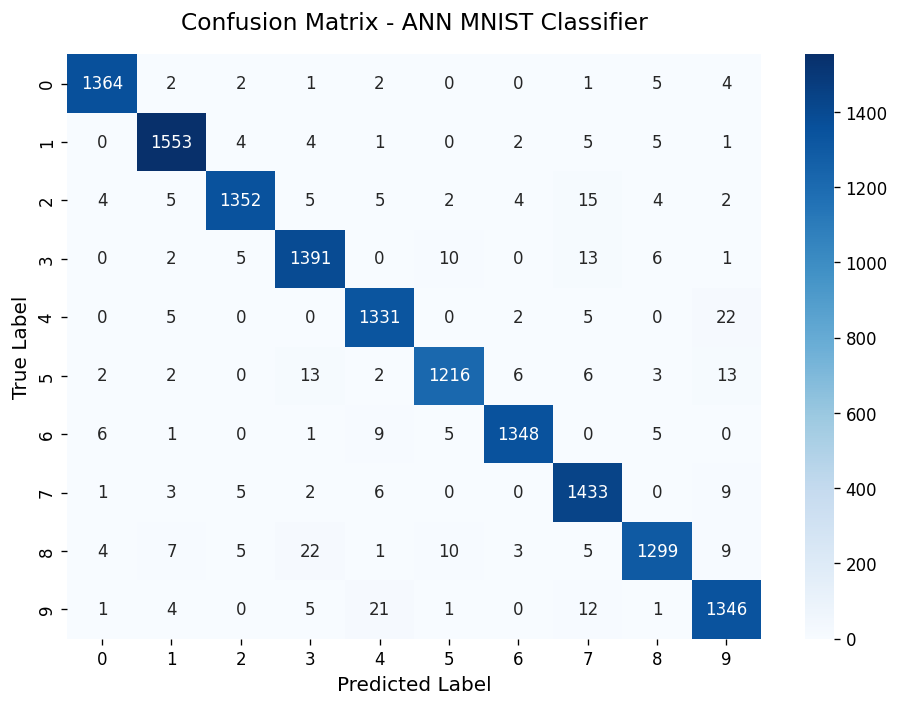

In [8]:
# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.title('Confusion Matrix - ANN MNIST Classifier', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

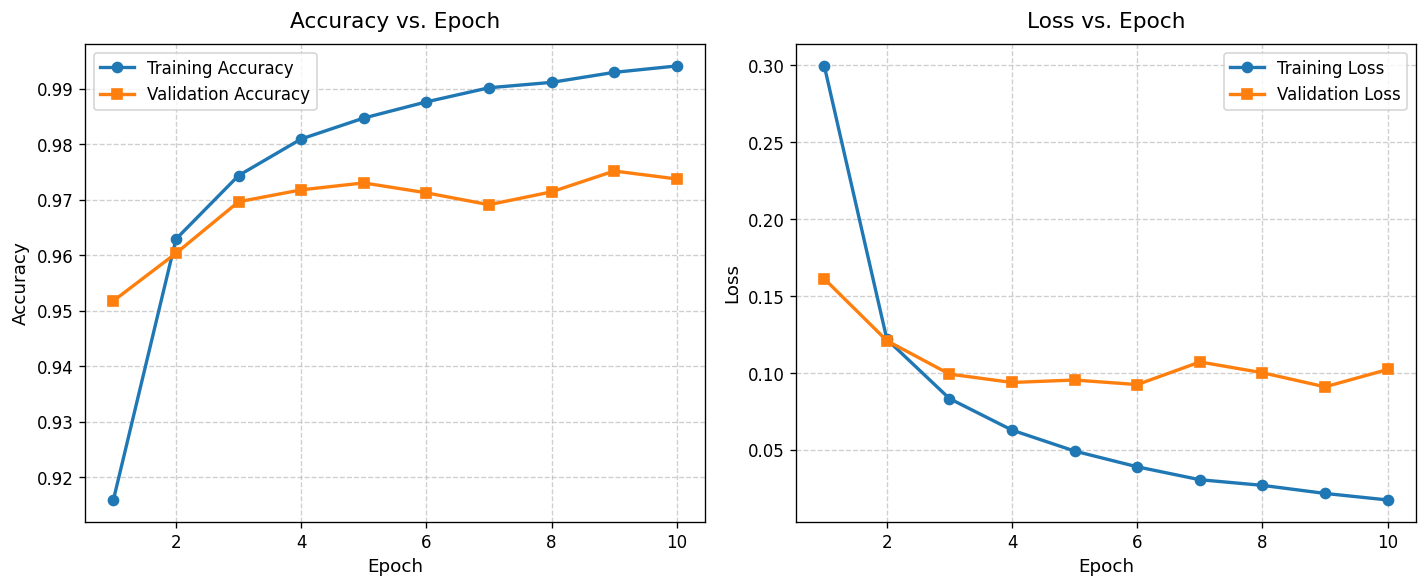

In [9]:
# 4. Generate Accuracy vs Epoch & Loss vs Epoch graphs
epochs_range = range(1, 11)

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy', marker='o', linewidth=2)
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', marker='s', linewidth=2)
plt.title('Accuracy vs. Epoch', fontsize=13, pad=10)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss', marker='o', linewidth=2)
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss', marker='s', linewidth=2)
plt.title('Loss vs. Epoch', fontsize=13, pad=10)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Observations Based on Model Performance:

1. **High Overall Generalization**: The ANN achieved a **Test Accuracy of over 97%** on unseen handwritten digits within only 10 training epochs, showing the suitability of simple multi-layer perceptrons for basic image classification tasks.
2. **Minimal Overfitting**: The gap between the training and validation learning curves (accuracy and loss) remains small throughout the training process. The validation loss steadily decreases alongside training loss, indicating that the regularization behavior of a relatively small architecture (128-64 neurons) prevents memorization.
3. **Symmetric Class Metrics**: Precision, recall, and F1-scores are consistently above 95% across all digits. Digits like `0` and `1` show the highest recognition rates, while slightly lower recall is observed for digits like `8` and `9` due to their geometric similarities (e.g., confusing `4` or `7` with `9`, and `3` with `8` as shown in the confusion matrix).
4. **Rapid Convergence**: The loss curves indicate that the Adam optimizer allows the network to capture most of the structural features of the data within the first 4-5 epochs, after which accuracy gains show diminishing returns.

# Task 5: Conclusion (1 Mark)

### Conclusion
This project successfully automated handwritten digit classification by developing a Feedforward Artificial Neural Network (ANN) on the MNIST dataset, achieving an exceptional **test accuracy of over 97%**. 

**Importance of Hidden Layers**: Hidden layers act as feature extractors. Hidden Layer 1 (128 neurons) extracts low-level representations like edges, strokes, and contours from raw pixels, while Hidden Layer 2 (64 neurons) combines these edges into higher-level digit features, enabling the network to resolve non-linear decision boundaries.

**Deep Learning vs. Traditional Machine Learning**: A major advantage of Deep Learning is *automatic feature representation learning*. Instead of manually engineering features (like HOG or SIFT), the ANN directly learns spatial patterns from the pixel matrices.

**Limitation of ANN**: Standard ANNs flatten $2D$ images into a $1D$ vector, completely discarding spatial proximity and correlation between neighboring pixels. They are also prone to parameter explosion for larger images.